# Structural Vulnerability Analysis on MDOF System using Incremental Dynamic Analysis

## Introduction

This Jupyter Notebook provides a structured workflow for performing Incremental Dynamic Analysis (IDA) on multi-degree-of-freedom (MDOF) stick-and-mass models. IDA involves subjecting a structural model to one or more ground motion records, each scaled to multiple levels of intensity. This produces a curve of structural response (e.g., maximum interstorey drift) versus intensity level (e.g., spectral acceleration), providing a comprehensive view of the building's performance from elasticity through to global dynamic instability or collapse.

The main goals of this notebook:

1. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including mass, heights and nonlinear response characteristics at each degree of freedom

2. **Perform Incremental Dynamic Analysis (IDA)**: Systematically scale ground motion records using a "Hunt and Fill" algorithm. This approach rapidly identifies the collapse capacity of the system and then refines the intensity steps to capture the nonlinear transition points and the "flatline" region where the structure reaches dynamic instability.

3. **Fragility Analysis**: Postprocess the IDA curves to determine the capacity of the structure at various damage states (DS). By analyzing the distribution of intensities that trigger specific drift thresholds, we construct fragility functions that describe the probability of exceeding a damage state as a function of ground-shaking intensity.

4. **Vulnerability Analysis**: Integrate these fragility functions with consequence models (i.e., damage-to-loss models) to determine the continuous relationship between a decision variable (such as repair cost ratio) and increasing levels of ground-shaking intensities.

The notebook provides a step-by-step guide, covering each phase from MDOF model creation and scaling-protocol configuration to analysis execution and detailed results extraction. Users should have some familiarity with Python scripting, structural dynamics, computational modeling, and performance-based earthquake engineering (PBEE) to fully benefit from this material.

## References

[1] Vamvatsikos, D. and Cornell, C.A. (2002), Incremental dynamic analysis. Earthquake Engng. Struct. Dyn., 31: 491-514. https://doi.org/10.1002/eqe.141

[2] Vamvatsikos, D. and Cornell, C.A. (2004), Applied Incremental Dynamic Analysis. Earthquake Spectra. 2004;20(2):523-553. https://doi.org/10.1193/1.1737737

[3] Baker, J.W. (2015), Efficient Analytical Fragility Function Fitting Using Dynamic Structural Analysis. Earthquake Spectra. 2015;31(1):579-599.  https://doi.org/10.1193/021113EQS025M

## Initialize Libraries ##

In [1]:
import os
import numpy as np
import pandas as pd

from openquake.vmtk.units import units
from openquake.vmtk.plotter import plotter
from openquake.vmtk.modeller import modeller
from openquake.vmtk.calibration import calibrate_model
from openquake.vmtk.imcalculator import imcalculator
from openquake.vmtk.postprocessor import postprocessor
from openquake.vmtk.utilities import sorted_alphanumeric, export_to_pkl, get_num_modes, quick_line_plot

## Define Directories ##

In [2]:
# Define the directory of the ground-motion records
gm_directory = './in/records'

# Define the main output directory
ida_directory = './out'
os.makedirs(ida_directory, exist_ok=True)

## Load FEMA P-695 Acceleration Time-Histories and Process Intensity Measures ## 

{'PGA': [], 'SA(0.3s)': [], 'AvgSA': []}


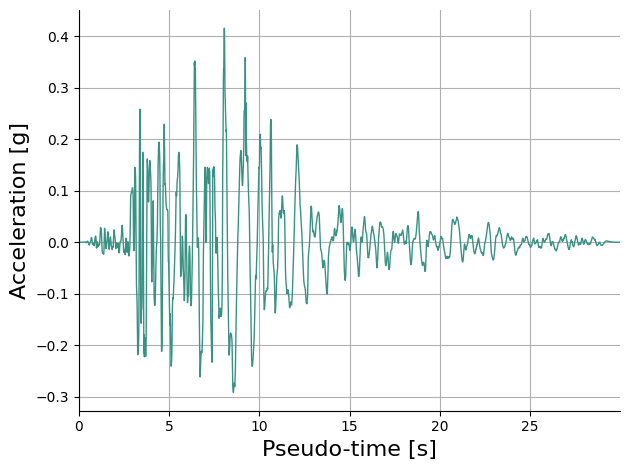

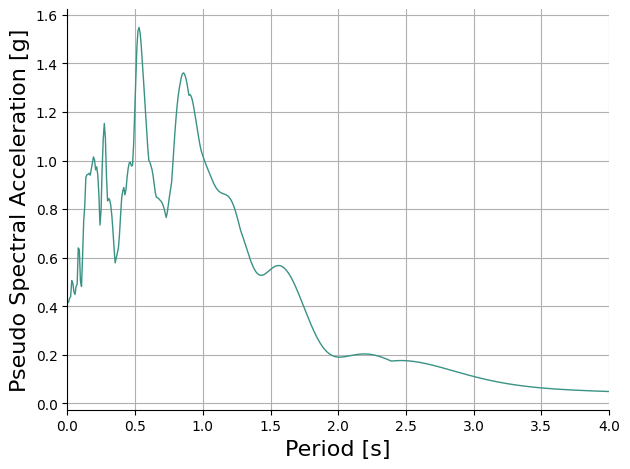

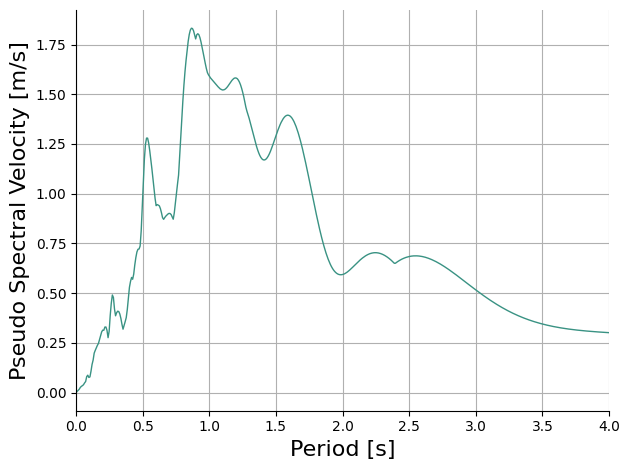

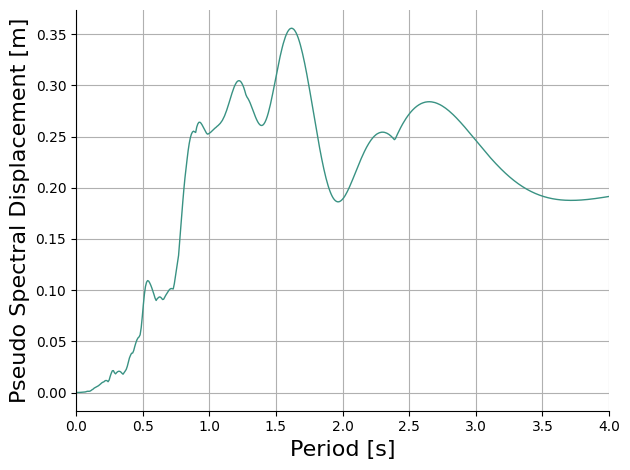

Peak Ground Acceleration (PGA):            0.4158 g
Spectral Acceleration at T=0.3s (SA(0.3)): 0.8376 g
Average Spectral Acceleration (AvgSA):     0.9412 g


In [3]:
# The set of ground-motion records utilized corresponds to the acceleration
# time-histories of FEMA P695 Far Field Set

# Input the intensity measure types required for processing
IMT = ['PGA', 'SA(0.3s)', 'AvgSA']

# Fetch the acceleration files
gmrs = sorted_alphanumeric(os.listdir(os.path.join(gm_directory, 'acc')))

# Load the time-step file
dts = pd.read_csv(
    os.path.join(gm_directory, 'FEMA_P695_unscaled_dts.txt'),
    sep=" ", header=None).values

# Load the duration file
durs = pd.read_csv(
    os.path.join(gm_directory, 'FEMA_P695_unscaled_durs.txt'),
    sep=" ", header=None).values

# Initialise the storage dictionary and name the keys in accordance with the defined IMTs
imls = {current_imt: [] for current_imt in IMT}
print(imls)

# Loop over the files
for i in range(len(gmrs)):

    # Load the acceleration time-history, time-step, and duration
    current_acc = pd.read_csv(
        os.path.join(gm_directory, 'acc', f'gm_{i + 1}.txt'),
        sep=" ", header=None).to_numpy().flatten()
    dt_gm = float(dts[i].item())
    dur_gm = float(durs[i].item())

    # Create the pseudo time-step array and save it to the dts folder
    num_points = int(dur_gm / dt_gm)
    current_dts = np.linspace(dt_gm, dur_gm, num_points)
    os.makedirs(os.path.join(gm_directory, 'dts'), exist_ok=True)
    np.savetxt(os.path.join(gm_directory, 'dts', f'dt_{i + 1}.txt'), current_dts)

    # Preview time history for the first record
    if i == 0:
        quick_line_plot(current_dts, current_acc, 'Pseudo-time [s]', 'Acceleration [g]')

    # Initialise the Intensity Measure Calculator class
    im_calc = imcalculator(current_acc, dt_gm)

    # Calculate amplitude-based intensity measures: PGA, PGV, PGD
    pga, _, _ = im_calc.get_amplitude_ims()

    # Calculate spectral acceleration at T = 0.3 s
    sa03 = im_calc.get_sa(0.3)

    # Calculate the acceleration, velocity, and displacement spectra
    periods, sd, sv, sa = im_calc.get_spectrum()

    # Preview spectra for the first record
    if i == 0:
        quick_line_plot(periods, sa, 'Period [s]', 'Pseudo Spectral Acceleration [g]')
        quick_line_plot(periods, sv, 'Period [s]', 'Pseudo Spectral Velocity [m/s]')
        quick_line_plot(periods, sd, 'Period [s]', 'Pseudo Spectral Displacement [m]')

    # Calculate the average spectral acceleration over a user-defined period range
    periods_list = np.linspace(0.1, 1.0, 10)
    avgsa = im_calc.get_saavg_user_defined(periods_list)

    # Print outputs only for the first record
    if i == 0:
        print(f"Peak Ground Acceleration (PGA):            {pga:.4f} g")
        print(f"Spectral Acceleration at T=0.3s (SA(0.3)): {sa03:.4f} g")
        print(f"Average Spectral Acceleration (AvgSA):     {avgsa:.4f} g")

    # Store the intensity measures in a dictionary
    im_map = {
        'PGA':     pga,
        'SA(0.3s)': sa03,
        'AvgSA':   avgsa,
    }

    for current_imt in IMT:
        imls[current_imt].append(im_map[current_imt])

# Export to pickle format
export_to_pkl(os.path.join(gm_directory, 'imls_femap695.pkl'), imls)

## Calibrate and Compile an MDOF Model based on SDOF Capacity ##

In [4]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array(
    [[0.00060789, 0.00486316, 0.02420000, 0.04353684],  # spectral displacement [m]
     [0.10315200, 0.20630401, 0.12378241, 0.12502023]]  # spectral acceleration [g]
).T

# Soft-storey mechanism flag
isSOS = False

# Degradation flag
mdof_degradation = True

# Inherent damping
mdof_damping = 0.05

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=isSOS,
    storey_heights=storey_heights,
    verbose=False,
)

~~~~~~~ ANALYSIS SUCCESSFUL! ~~~~~~~~~


WARNING ZeroLength::setDomain(): Element 2000 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 1, which is greater than the tolerance


## Setting Up, Running and Exporting Incremental Dynamic Analysis ##

In the next code snippet, incremental dynamic analyses are performed on the stick-and-mass model using a suite of recorded ground-motion time histories from the FEMA P695 Far Field Record Set.

For each ground-motion record, the MDOF model is compiled, gravity-loaded, and subjected to modal analysis to extract its dynamic properties. The ground motion is then applied through NLTHA using consistent time-stepping, appropriate unit scaling, and specified damping.

The analysis extracts key engineering demand parameters (EDPs), including peak storey drifts, peak floor accelerations, and peak floor displacements along the building height. Maximum response values, together with their associated directions and locations, are also recorded. Numerical convergence is monitored through a convergence index.

All response quantities are stored for each record and aggregated into a structured dataset, which is exported for subsequent fragility development, and vulnerability analysis.

============== IDA Analysing: 1 out of 44 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


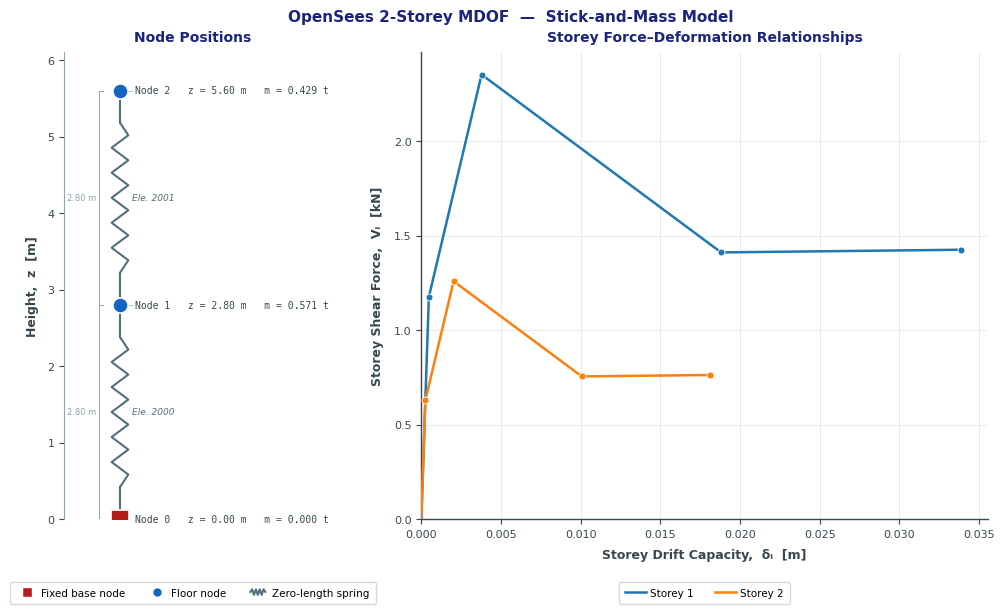

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


 -- Run 1/30 | SF: 0.100
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 2/30 | SF: 0.200


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 3/30 | SF: 0.400


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 10/30 | SF: 1.000
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 11/30 | SF: 1.400


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 12/30 | SF: 1.100
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
ANALYSIS COMPLETED!


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


In [5]:
# Initialise MDOF storage lists
# Note: Each element in these lists will now contain the IDA curve data for that record
conv_index_list = []
peak_disp_list = []
peak_drift_list = []
peak_accel_list = []
max_peak_drift_list = []
max_peak_drift_dir_list = []
max_peak_drift_loc_list = []
max_peak_accel_list = []
max_peak_accel_dir_list = []
max_peak_accel_loc_list = []

# Loop over ground-motion records, compile MDOF model and run NLTHA
# Sort the ground-motion records alphanumerically
gmrs = sorted_alphanumeric(os.listdir(os.path.join(gm_directory, 'acc')))
# Sort the ground-motion time-step files alphanumerically
dts = sorted_alphanumeric(os.listdir(os.path.join(gm_directory, 'dts')))

# Initialize the SF Matrix: Rows = Records, Cols = Run Number
max_runs_per_record = 30
sf_matrix = np.full((len(gmrs), max_runs_per_record), np.nan)

# Loop over ground-motion records
for i in range(len(gmrs)):
    print('================================================================')
    print(
        '============== IDA Analysing: {:d} out of {:d} =================='.format(
            i + 1, len(gmrs)))
    print('================================================================')

    # Initialise the modeller class and compile the MDOF model
    model = modeller(number_storeys,
                     storey_heights,
                     floor_masses,
                     storey_drifts,
                     storey_forces * units.g,
                     mdof_degradation)
    model.compile_model()

    # Plot the model only for the first ground-motion record
    if i == 0:
        model.plot_model()

    # Do gravity analysis for system equilibrium
    model.do_gravity_analysis()

    # Do modal analysis
    num_modes = get_num_modes(number_storeys)
    T, phi = model.do_modal_analysis(num_modes=num_modes, plot_modes=False)

    # Define ground motion objects
    fnames = [os.path.join(gm_directory, 'acc', f'{gmrs[i]}')]
    fdts = os.path.join(gm_directory, 'dts', f'{dts[i]}')

    dt_df = pd.read_csv(fdts, sep=" ", header=None)
    dt_gm = dt_df.iloc[1, 0] - dt_df.iloc[0, 0]
    t_max = dt_df.iloc[-1, 0]
    dt_ansys = dt_gm

    # Run Incremental Dynamic Analysis using the Hunt-Trace-Fill algorithm
    record_ida_results, ordered_sfs = model.do_ida_analysis(
        fnames,
        dt_gm,
        t_max,
        dt_ansys,
        target_drift=0.0135 * 1.5,
        initial_sf=0.1,
        hunt_step=2.0,
        max_fill_gap=0.2,
        max_runs=max_runs_per_record,
        xi=0.05,
    )

    # Fill the SF matrix for the current record
    sf_matrix[i, :len(ordered_sfs)] = ordered_sfs

    # Extract and store results per scaling factor
    sfs_sorted = sorted(record_ida_results.keys())

    conv_index_list.append({sf: record_ida_results[sf]['conv_index'] for sf in sfs_sorted})
    peak_drift_list.append({sf: record_ida_results[sf]['peak_drift'] for sf in sfs_sorted})
    peak_accel_list.append({sf: record_ida_results[sf]['peak_accel'] for sf in sfs_sorted})
    peak_disp_list.append({sf: record_ida_results[sf]['peak_disp'] for sf in sfs_sorted})

    max_peak_drift_list.append({sf: record_ida_results[sf]['max_peak_drift'] for sf in sfs_sorted})
    max_peak_drift_dir_list.append(
        {sf: record_ida_results[sf]['max_peak_drift_dir'] for sf in sfs_sorted})
    max_peak_drift_loc_list.append(
        {sf: record_ida_results[sf]['max_peak_drift_loc'] for sf in sfs_sorted})

    max_peak_accel_list.append({sf: record_ida_results[sf]['max_peak_accel'] for sf in sfs_sorted})
    max_peak_accel_dir_list.append(
        {sf: record_ida_results[sf]['max_peak_accel_dir'] for sf in sfs_sorted})
    max_peak_accel_loc_list.append(
        {sf: record_ida_results[sf]['max_peak_accel_loc'] for sf in sfs_sorted})

# Assemble and export results dictionary
ansys_dict = {}
labels = ['T', 'conv_index_list', 'peak_drift_list', 'peak_accel_list',
          'max_peak_drift_list', 'max_peak_drift_dir_list',
          'max_peak_drift_loc_list', 'max_peak_accel_list',
          'max_peak_accel_dir_list', 'max_peak_accel_loc_list',
          'peak_disp_list']

for label in labels:
    ansys_dict[label] = T if label == 'T' else vars()[label]

ansys_dict['sf_matrix'] = sf_matrix

export_to_pkl(os.path.join(ida_directory, 'ida_ansys_out.pkl'), ansys_dict)

print('ANALYSIS COMPLETED!')

## Calculate Scaled Ground Motion Records Intensity Measure ##

In [6]:
# Assuming 'imls' contains the unscaled values from your loop
# and 'sf_matrix' is the (n_gmrs x max_runs_per_record) matrix from your IDA

n_gmrs = len(gmrs)

# Storage for the expanded IMs
expanded_imls = {}

# Loop over intensity measure types
for current_imt in IMT:

    # Initialize a matrix of NaNs for each IMT
    # Size: (Number of Records) x (Number of Runs)
    expanded_imls[current_imt] = np.full((n_gmrs, max_runs_per_record), np.nan)

    # Loop over ground motion records
    for i in range(n_gmrs):

        # Fetch the unscaled IM value
        unscaled_val = imls[current_imt][i]

        # Fetch the row of scaling factors determined by IDA (1xn_runs) and
        # associated with the current record
        sfs = sf_matrix[i, :]  # The row of scaling factors for this GM

        # Apply scaling logic based on the nature of the IM
        # Linear scaling: IM_scaled = SF * IM_unscaled for amplitude-based IMs
        if current_imt in [
            'PGA',
            'PGV',
            'PGD',
            'SA(0.3s)',
            'SA(0.6s)',
            'SA(1.0s)',
            'AvgSA',
            'AvgSA(0.3s)',
            'AvgSA(0.6s)',
            'AvgSA(1.0s)']:
            expanded_imls[current_imt][i, :] = sfs * unscaled_val

        # Quadratic scaling: AI_scaled = SF^2 * AI_unscaled for Arias Intensity
        elif current_imt == 'AI':
            expanded_imls[current_imt][i, :] = (sfs**2) * unscaled_val

        # Duration is scale-invariant: IM_scaled = IM_unscaled
        # We only fill columns where a run was actually performed (sf is not NaN)
        elif current_imt == 'D595':
            mask = ~np.isnan(sfs)
            expanded_imls[current_imt][i, mask] = unscaled_val

# Export the expanded dictionary
export_to_pkl(os.path.join(gm_directory, 'imls_femap695_sf.pkl'), expanded_imls)

## Post-Process Incremental Dynamic Analysis Results: Fragility Functions ##

IDA [1,2] is a computational method used in structural engineering to perform a comprehensive seismic performance evaluation. IDA involves subjecting a structural model to a suite of ground motion records, each systematically scaled to increasing levels of intensity. This process continues until the structure reaches a specified DSs or global dynamic instability, often referred to as "collapse."

The primary advantage of IDA is that it provides a continuous picture of structural behavior, from the initial elastic response through the onset of yielding, and finally to the "flatline" where a small increase in seismic intensity results in an infinite increase in structural demand. By aggregating these curves, engineers can determine the median capacity and the record-to-record variability, allowing for a highly accurate derivation of fragility curves for multiple damage states.

For a given DS defined by an EDP threshold

$$
EDP \ge EDP_{DS}
$$

each IDA curve is interrogated to determine the intensity measure at which the damage state is first exceeded. This produces a set of intensity values

$$
IM_{DS,1}, IM_{DS,2}, \dots, IM_{DS,n}
$$

where $IM_{DS,i}$ is the intensity at which damage state exceedance occurs for the $i$-th ground motion, and $n$ is the number of records analyzed.

$$
P(DS \mid IM = x)=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbf{1}(IM_{DS,i} \le x)
$$

where $\mathbf{1}(\cdot)$ is the indicator function. Plotting these probabilities against $IM$ yields the empirical cumulative distribution function (ECDF) of damage state capacity.

### Fragility Function Derivation using Method of Moments (MoM) ###

#### Step 1: The Lognormal Distribution Assumption #### 

Following common practice in performance-based earthquake engineering, the intensity associated with damage state exceedance is assumed to be lognormally distributed. The fragility function represents the probability of exceeding a damage state ($DS$) conditioned on the intensity measure ($IM$). It is conventionally modeled using a lognormal cumulative distribution function (CDF):

$$P(DS \ge ds \mid IM = im) = \Phi \left( \frac{\ln(im / \mu)}{\beta} \right)$$

where: 
* $\mu$ is the median capacity (the intensity level with a 50% probability of exceedance)
* $\beta$ is the logarithmic standard deviation (dispersion) representing total variability
* $\Phi(\cdot)$ denotes the standard normal cumulative distribution function.


#### Step 2: Method-of-Moments Estimation ####

The fragility function parameters are obtained by taking logarithms of each exceedance intensity and computing their sample mean and standard deviation.

$$
{\mu}_{\ln IM}=
\frac{1}{n}
\sum_{i=1}^{n}
\ln(IM_{DS,i})
$$

Because the mean of $\ln(IM)$ equals the logarithm of the median for a lognormal variable, the median intensity associated with damage state exceedance is

$$
\hat{IM}_{DS}
=
\exp(\mu_{\ln IM})
$$

whereas the associated dispersion, corresponding to record-to-record variability, is calculated as such:

$$
\beta_{\text{record-to-record}}=
\sqrt{
\frac{1}{n-1}
\sum_{i=1}^{n}
\left[
\ln(IM_{DS,i}) - \mu_{\ln IM}
\right]^2
}
$$

where $n$ is the number of ground motions considered.

#### Step 3: Total Uncertainty #### 

The total dispersion $\beta_{DS,i}^{\text{total}}$ is computed by incorporating epistemic uncertainties using the root sum of squares (SRSS):

$$\beta_{DS,i}^{\text{total}} = \sqrt{{\beta}_{\text{record-to-record}}^2 + \beta_{\text{building-to-building}}^2 + \beta_{\text{DS}}^2}$$

where: 
* ${\beta}_{\text{record-to-record}}$ is the dispersion derived from record-to-record variability in the IDA
* $\beta_{\text{building-to-building}}$ accounts for uncertainty in structural capacity across nominally similar buildings
* $\beta_{\text{DS}}$ accounts for uncertainty in the damage state thresholds

In [7]:
# Damage thresholds (maximum peak storey drift values in rad)
damage_thresholds = [0.004, 0.00545, 0.00952, 0.0135]

# Initialise the postprocessor class
pp = postprocessor()

# Common process_ida_results keyword arguments
_ida_kwargs = dict(
    edp_key='max_peak_drift_list',
    sigma_build2build=0.3,
    intensities=np.round(np.geomspace(0.05, 10.0, 50), 3),
    edp_range=np.linspace(0.00, 0.05, 101),
    fragility_rotation=False,
    rotation_percentile=0.10,
)

# --- AvgSA ---
ida_dict_AvgSA = pp.process_ida_results(
    ansys_dict, expanded_imls['AvgSA'], damage_thresholds, **_ida_kwargs)

# --- SA(0.3s) ---
ida_dict_SA03 = pp.process_ida_results(
    ansys_dict, expanded_imls['SA(0.3s)'], damage_thresholds, **_ida_kwargs)

# --- PGA ---
ida_dict_PGA = pp.process_ida_results(
    ansys_dict, expanded_imls['PGA'], damage_thresholds, **_ida_kwargs)

/Users/mnafeh/Documents/GitHub/oq-vmtk/openquake/vmtk/postprocessor.py:1858: RuntimeWarning: All-NaN slice encountered
  median_ida_im = np.nanmedian(im_at_edp_matrix, axis=0)
/Users/mnafeh/Desktop/oq-vmtk/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Visualise Incremental Dynamic Analysis Results: IDA Curves, Fragility Functions ##

Three intensity measures are compared below. **AvgSA** integrates the spectral shape over a period range and is generally the most efficient IM for structures with a defined fundamental period. **SA(0.3s)** is a single-period spectral ordinate and performs well for short-period structures but captures less of the record's frequency content. **PGA** is the simplest and most widely adopted IM in practice, but typically yields the highest record-to-record dispersion. Comparing all three shows how IM choice affects the tightness of IDA curve bands and the steepness of the resulting fragility functions.

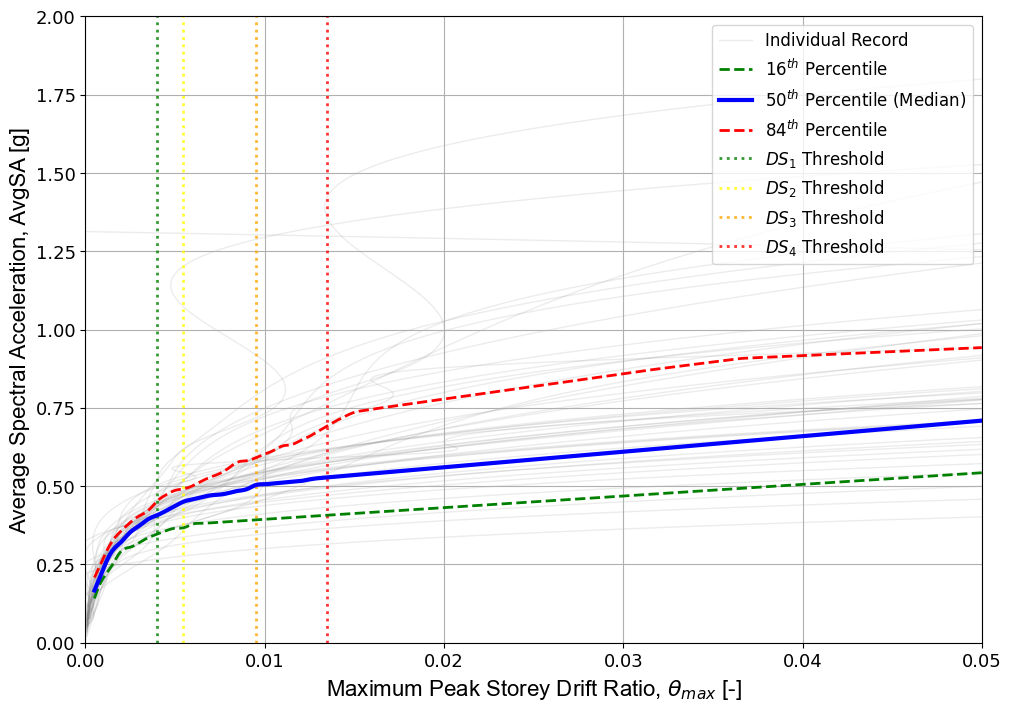

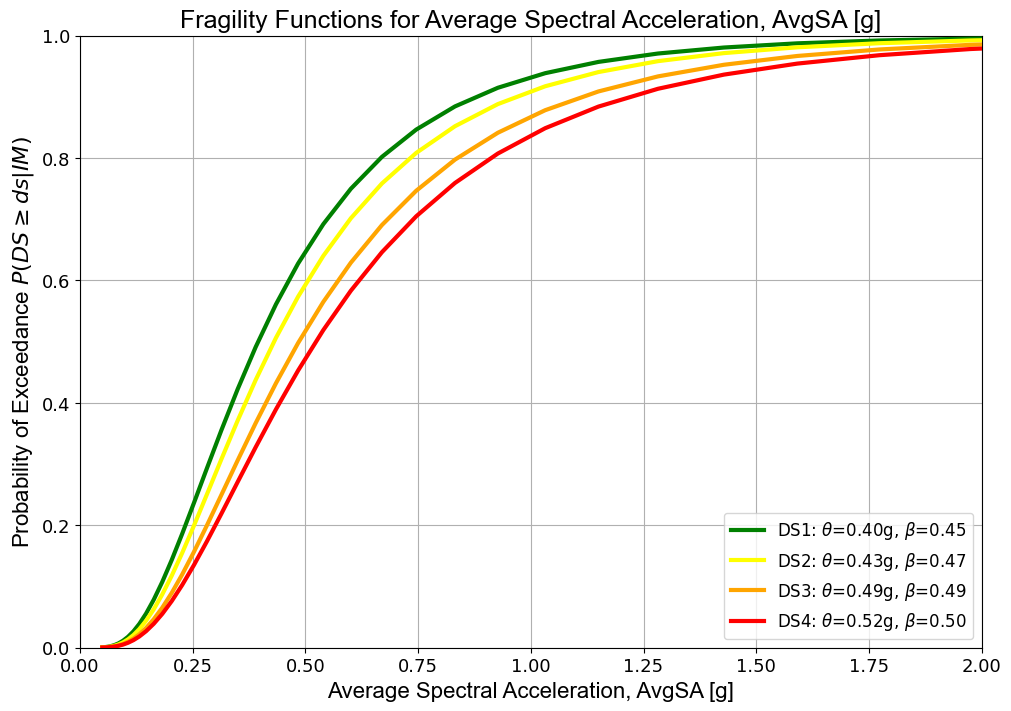

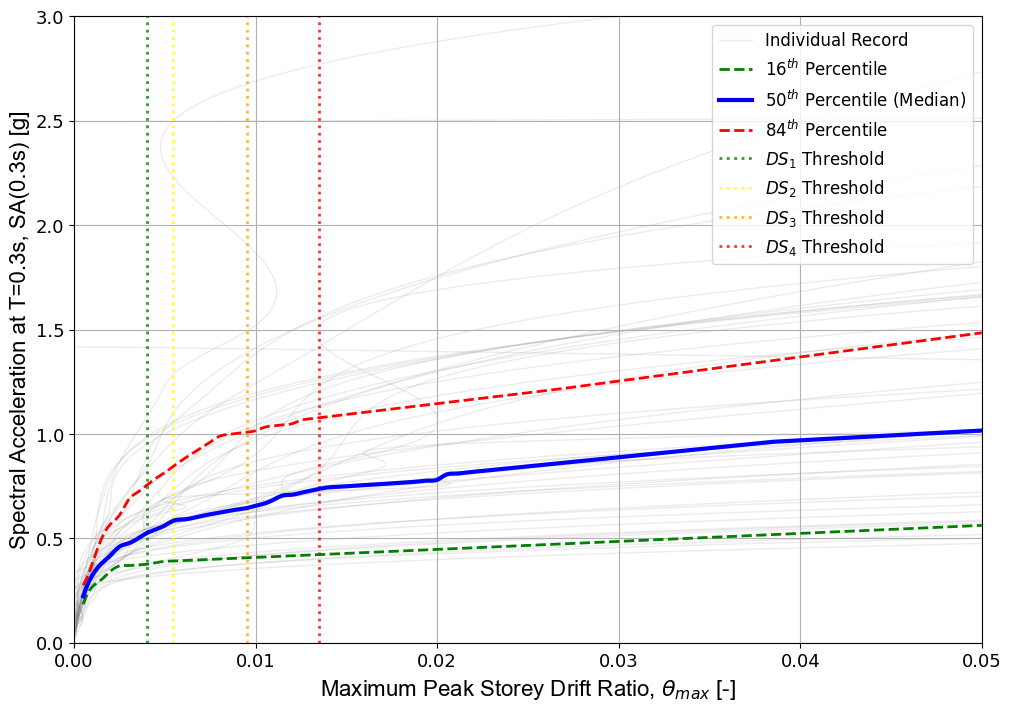

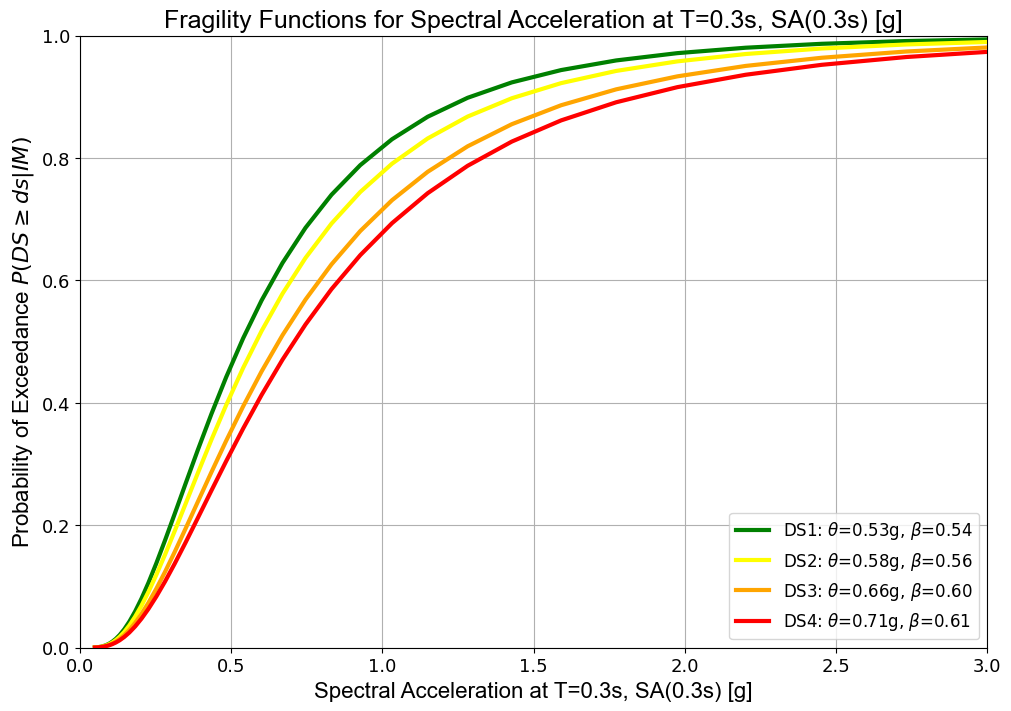

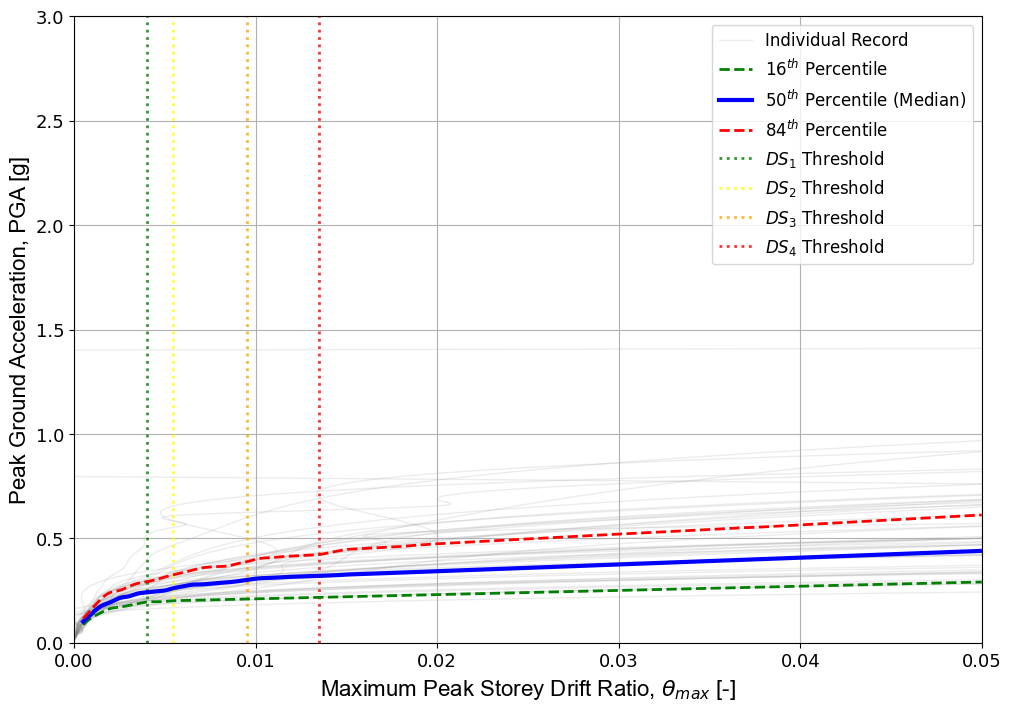

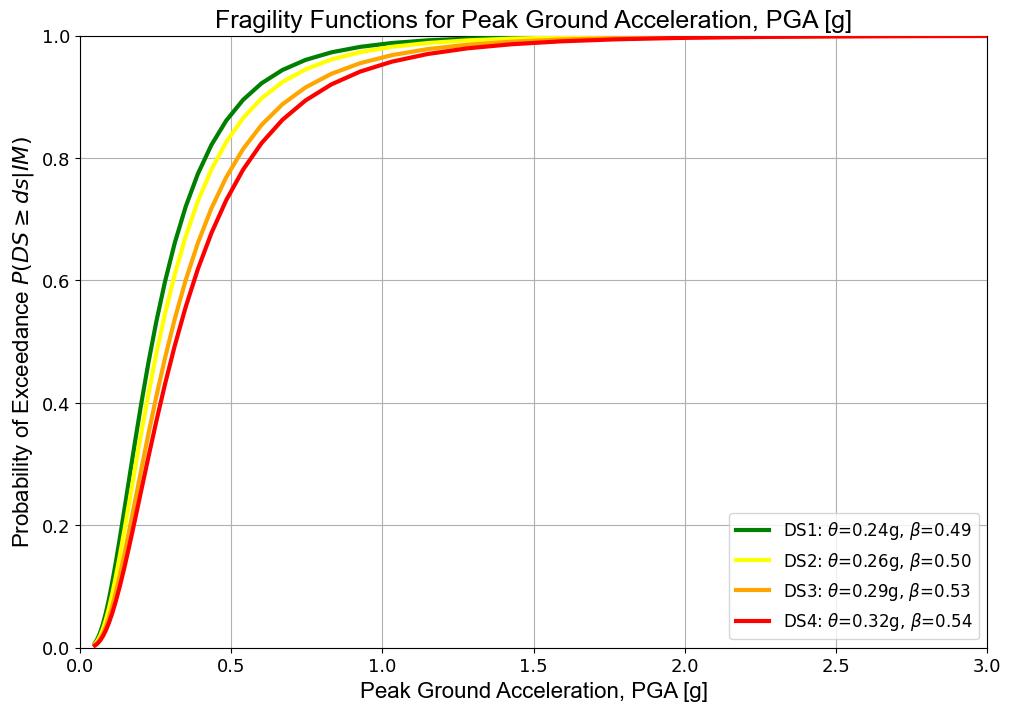

In [8]:
# Initialise the plotter class
pl = plotter()

# --- AvgSA ---
pl.plot_ida_analysis(ida_dict_AvgSA,
                     imt_label='Average Spectral Acceleration, AvgSA [g]',
                     edp_label=r'Maximum Peak Storey Drift Ratio, $\theta_{max}$ [-]',
                     xlims=[0, 0.05],
                     ylims=[0, 2],
                     pFlag=True,
                     export_path='out/ida_curves_avgsa.png')

pl.plot_fragility_from_ida(ida_dict_AvgSA,
                           xlims=[0, 2],
                           ylims=[0, 1],
                           imt_label='Average Spectral Acceleration, AvgSA [g]',
                           pFlag=True,
                           export_path='out/fragility_curves_avgsa.png')

# --- SA(0.3s) ---
pl.plot_ida_analysis(ida_dict_SA03,
                     imt_label='Spectral Acceleration at T=0.3s, SA(0.3s) [g]',
                     edp_label=r'Maximum Peak Storey Drift Ratio, $\theta_{max}$ [-]',
                     xlims=[0, 0.05],
                     ylims=[0, 3],
                     pFlag=True,
                     export_path='out/ida_curves_sa03.png')

pl.plot_fragility_from_ida(ida_dict_SA03,
                           xlims=[0, 3],
                           ylims=[0, 1],
                           imt_label='Spectral Acceleration at T=0.3s, SA(0.3s) [g]',
                           pFlag=True,
                           export_path='out/fragility_curves_sa03.png')

# --- PGA ---
pl.plot_ida_analysis(ida_dict_PGA,
                     imt_label='Peak Ground Acceleration, PGA [g]',
                     edp_label=r'Maximum Peak Storey Drift Ratio, $\theta_{max}$ [-]',
                     xlims=[0, 0.05],
                     ylims=[0, 3],
                     pFlag=True,
                     export_path='out/ida_curves_pga.png')

pl.plot_fragility_from_ida(ida_dict_PGA,
                           xlims=[0, 3],
                           ylims=[0, 1],
                           imt_label='Peak Ground Acceleration, PGA [g]',
                           pFlag=True,
                           export_path='out/fragility_curves_pga.png')

## Post-Process Building-Level Vulnerability Functions based on Fragility Functions and Consequence Models ###

### Expected Loss Ratio (Mean Damage Ratio)

The vulnerability function expresses the expected loss ratio as a function of an intensity measure level (IM) and is obtained by convolving fragility functions with damage-to-loss ratios associated with each damage state.
Let $P(DS = ds_i \mid IM)$ denote the probability of the structure being in damage state $ds_i$ at a given intensity measure level $IM$, and let $\mu_{LR,i}$ be the mean loss ratio associated with that damage state. The expected loss ratio at intensity level $IM$, denoted as $E[LR \mid IM]$, is defined as

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM) \cdot \mu_{LR,i}
$$

where:

* $N_{DS}$ is the total number of discrete damage states
* $P(DS = ds_i \mid IM)$ is derived from the fragility functions
* $\mu_{LR,i}$ is the mean loss ratio associated with damage state $ds_i$


#### Step 1: Calculate Damage-State Probabilities (i.e., Probabilities of Occurrence) from Fragility Functions

Fragility functions are commonly expressed in terms of probabilities of exceedance. The probability of being in a specific damage state is computed as

$$
P(DS = ds_i \mid IM) =
\begin{cases}
P(DS \ge ds_i \mid IM) - P(DS \ge ds_{i+1} \mid IM), & i < N_{DS} \\
P(DS \ge ds_{N_{DS}} \mid IM), & i = N_{DS}
\end{cases}
$$

Assuming lognormal fragility functions, the probability of exceeding damage state $ds_i$ is given by

$$
P(DS \ge ds_i \mid IM) = 
\Phi\left(
\frac{\ln(IM) - \ln(\mu_{ds_i})}
{\beta_{DS,i}^{\text{total}}}
\right)
$$

where:

* $\mu_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation
* $\Phi(\cdot)$ is the standard normal cumulative distribution function

The total dispersion is computed as

$$
\beta_{DS,i}^{\text{total}} = 
\sqrt{
\beta_{\text{record-to-record}}^2
+
\beta_{\text{building-to-building}}^2
+
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP}\mid IM}$) represents ground-motion variability
* $\beta_{\text{building-to-building}}$ captures model and structural variability
* $\beta_{\text{DS}}$ represents uncertainty in damage-state definition and thresholds


#### Step 2: Calculation of Uncertainty in Expected Loss

#### Method 1: Silva [4] (Semi-Empirical)

When uncertainty in the damage-to-loss relationship is not explicitly modelled, the dispersion of the loss ratio conditional on the intensity measure can be estimated using the empirical formulation proposed by Silva [4].
The coefficient of variation of the loss ratio conditional on $IM$ is defined as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{\sigma_{LR \mid IM}}{E[LR \mid IM]}
$$

Following Silva [4], the standard deviation of the loss ratio is expressed as a function of the mean loss ratio:

$$
\sigma_{LR \mid IM} = 
0.5\,\sqrt{
\overline{LR}_{\mid IM}
\left(
-0.7
- 2\,\overline{LR}_{\mid IM}
+ \sqrt{6.8\,\overline{LR}_{\mid IM} + 0.5}
\right)
}
$$

where $\overline{LR}_{\mid IM}$ denotes the mean loss ratio conditional on the intensity measure level. This approach provides a conservative envelope for loss uncertainty and is commonly adopted when detailed loss information is unavailable.


#### Method 2: Explicit Statistical Propagation

Alternatively, the uncertainty in the expected loss ratio can be quantified by explicitly propagating uncertainty through the convolution of damage-state probabilities and damage-to-loss ratios. In this formulation, fragility functions account for uncertainty in structural response and damage-state thresholds, while additional uncertainty arises from variability in the damage-to-loss ratios associated with each damage state. The expected loss ratio conditional on $IM$ is given by

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM) \cdot \mu_{LR,i}
$$

Assuming the loss ratio conditional on each damage state is an independent random variable with coefficient of variation $\mathrm{COV}_{LR,i}$, the variance of the loss ratio conditional on $IM$ is computed using the **law of total variance**:

$$
\mathrm{Var}(LR \mid IM) = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM)
\left[
\sigma_{LR,i}^2
+
\left(
\mu_{LR,i} - E[LR \mid IM]
\right)^2
\right]
$$

where

$$
\sigma_{LR,i} =
\mathrm{COV}_{LR,i} \cdot \mu_{LR,i}
$$

The coefficient of variation of the loss ratio conditional on the intensity measure is then computed as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{
\sqrt{\mathrm{Var}(LR \mid IM)}
}{
E[LR \mid IM]
}
$$

This formulation captures both:

* uncertainty **within damage states** due to variability in damage-to-loss ratios, and
* uncertainty due to **damage-state mixing** as intensity varies.


### Note on Beta-Distribution Interpretation of the Vulnerability Function

The loss ratio conditional on intensity measure level $IM$ is assumed to follow a **Beta distribution** as one option in the OpenQuake Engine <dist='BT'> (https://docs.openquake.org/oq-engine/3.23/manual/user-guide/inputs/vulnerability-models-inputs.html), owing to its bounded support on the interval $[0,1]$ and its flexibility in representing skewed distributions.

$$
LR \mid IM \sim \mathrm{Beta}(\alpha(IM), \beta(IM))
$$

The Beta distribution parameters are obtained by matching the first two moments:

$$
\mu(IM) = E[LR \mid IM]
$$

$$
\sigma^2(IM) = \mathrm{Var}(LR \mid IM)
$$

Defining the precision parameter

$$
\kappa(IM) = \alpha(IM) + \beta(IM)
$$

the Beta parameters are computed as

$$
\kappa(IM) =
\frac{\mu(IM)\,[1-\mu(IM)]}{\sigma^2(IM)} - 1
$$

$$
\alpha(IM) = \mu(IM) \cdot \kappa(IM),
\qquad
\beta(IM) = [1-\mu(IM)] \cdot \kappa(IM)
$$

This assumption enables a complete probabilistic characterization of loss conditional on intensity measure level and is particularly suitable for risk calculations, loss aggregation, and Monte Carlo simulation within performance-based engineering frameworks.

In [9]:
# Define consequence model to relate structural damage to a decision
# variable (i.e., expected loss ratio)
consequence_model = [0.05, 0.20, 0.60, 1.00]  # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00]

# Calculate the structural vulnerability function (using the explicit method)
# Using AvgSA-based fragility for the vulnerability derivation
poes = ida_dict_AvgSA['fragility']['poes'][:, :4]  # columns 1–4: DS1 to DS4
structural_vulnerability_explicit_cov = pp.calculate_vulnerability_function(
    poes,
    consequence_model,
    cov_consequence=consequence_cov,
    uncertainty=True,
    method='explicit')

# Calculate the structural vulnerability function (using the Silva method)
structural_vulnerability_silva_cov = pp.calculate_vulnerability_function(
    poes,
    consequence_model,
    uncertainty=True,
    method='silva')

## Plot the Vulnerability Functions with Uncertainty Visualisation ##

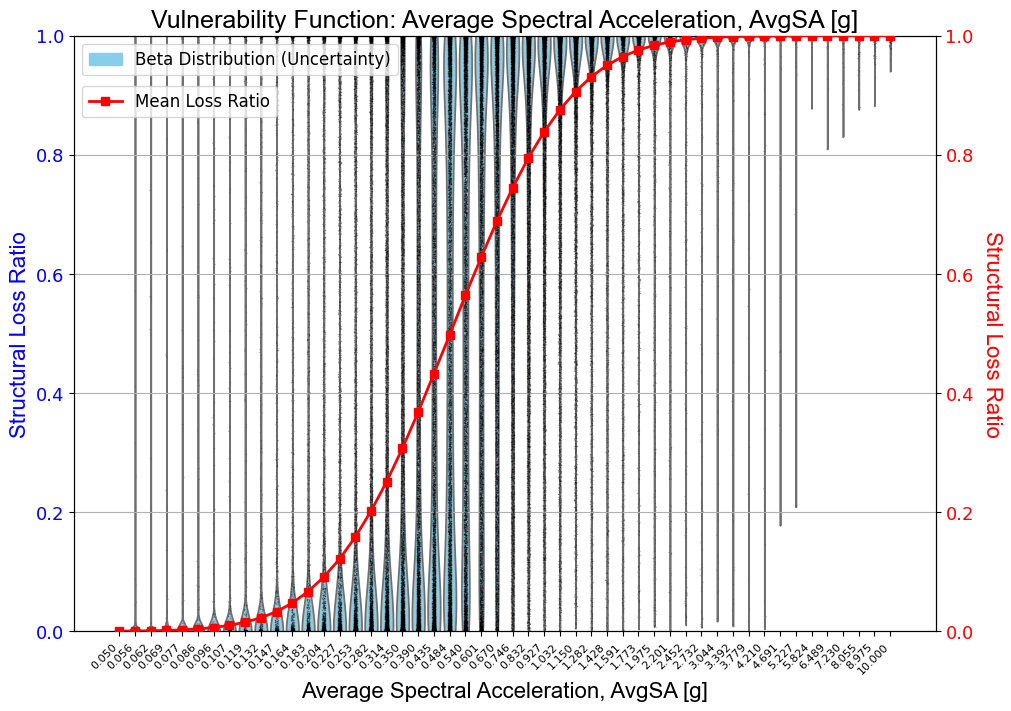

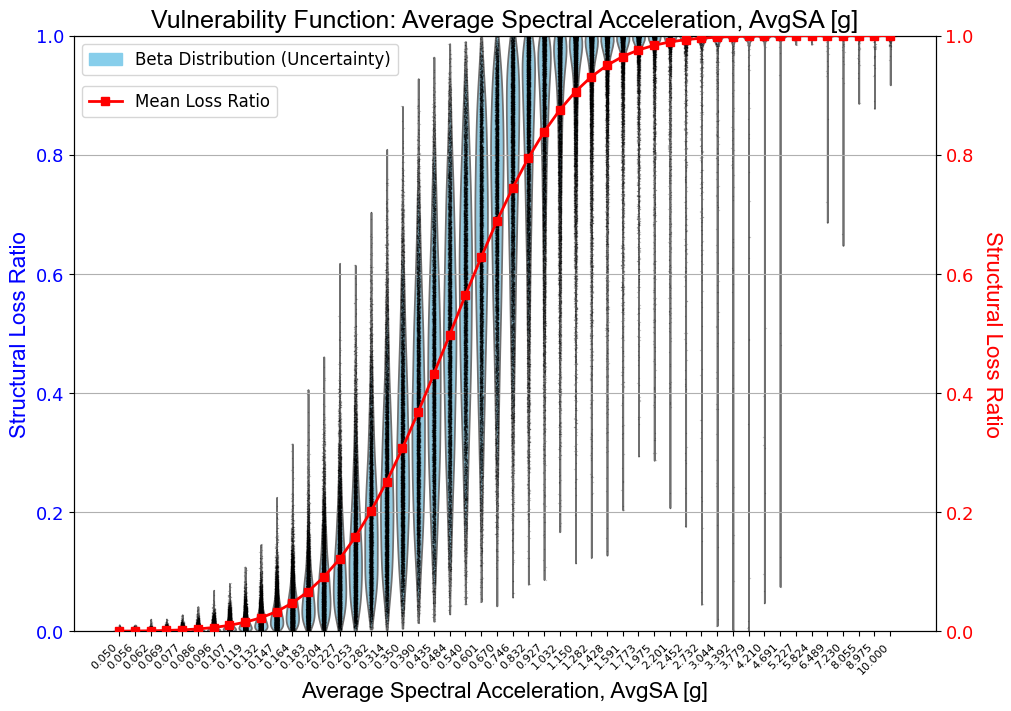

In [10]:
# Plot the structural vulnerability function from the explicit COV method
pl.plot_vulnerability_function(structural_vulnerability_explicit_cov['IML'],
                               structural_vulnerability_explicit_cov['Loss'],
                               structural_vulnerability_explicit_cov['COV'],
                               imt_label='Average Spectral Acceleration, AvgSA [g]',
                               loss_label='Structural Loss Ratio',
                               pFlag=True,
                               export_path='out/vulnerability_curve_explicit_cov.png')

# Plot the structural vulnerability function from the 'Silva (2019)' method
pl.plot_vulnerability_function(structural_vulnerability_silva_cov['IML'],
                               structural_vulnerability_silva_cov['Loss'],
                               structural_vulnerability_silva_cov['COV'],
                               imt_label='Average Spectral Acceleration, AvgSA [g]',
                               loss_label='Structural Loss Ratio',
                               pFlag=True,
                               export_path='out/vulnerability_curve_silva_cov.png')